# LendingClub data processing
Loads the accepted and rejected files, cleans them into one shared schema for the propensity model, and builds the outcome dataset for the outcome model.

In [1]:
!pip install kagglehub

In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download('wordsforthewise/lending-club')

Using Colab cache for faster access to the 'lending-club' dataset.


In [4]:
print(path)

/kaggle/input/lending-club


In [ ]:
import os
import gc
import pandas as pd
import numpy as np

In [6]:
files = os.listdir(path)

In [7]:
files

['rejected_2007_to_2018Q4.csv.gz',
 'accepted_2007_to_2018Q4.csv.gz',
 'accepted_2007_to_2018q4.csv',
 'rejected_2007_to_2018q4.csv']

## Load
Compact dtypes and only the needed accepted columns keep memory low (~27M rejected rows).

In [ ]:
REJ_PATH = os.path.join(path, 'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv')

# compact dtypes: repeated text as categories, floats as float32, dates parsed on load
rejected = pd.read_csv(
    REJ_PATH,
    dtype={'Amount Requested': 'float32', 'Risk_Score': 'float32', 'Policy Code': 'float32',
           'Loan Title': 'category', 'Debt-To-Income Ratio': 'category', 'Zip Code': 'category',
           'State': 'category', 'Employment Length': 'category'},
    parse_dates=['Application Date'], date_format='%Y-%m-%d',
)

In [ ]:
ACC_PATH = os.path.join(path, 'accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv')

# only the 24 columns used below (of 151)
ACC_COLS = ['id', 'loan_amnt', 'issue_d', 'title', 'purpose', 'fico_range_low', 'fico_range_high',
            'dti', 'zip_code', 'addr_state', 'emp_length', 'loan_status', 'term',
            'annual_inc', 'home_ownership', 'verification_status', 'revol_bal', 'revol_util',
            'open_acc', 'total_acc', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'mort_acc']
accepted = pd.read_csv(ACC_PATH, usecols=ACC_COLS, dtype={'id': str})

In [10]:
rejected

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0
...,...,...,...,...,...,...,...,...,...
27648736,10000.0,2016-12-31,Debt consolidation,590.0,41.26%,441xx,OH,< 1 year,0.0
27648737,10000.0,2016-12-31,moving,NaN,1.48%,207xx,MD,5 years,0.0
27648738,1200.0,2016-12-31,Other,686.0,10.26%,914xx,CA,< 1 year,0.0
27648739,25000.0,2016-12-31,debt_consolidation,NaN,17.71%,880xx,NM,< 1 year,0.0


In [ ]:
# no .copy(): a full copy doubles memory. drop_duplicates already returns a new frame,
# so the raw rejected data can be freed straight away
rejected_copy = rejected.drop_duplicates()
del rejected
gc.collect()

accepted_copy = accepted

In [12]:
rejected_copy.columns

Index(['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score',
       'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length',
       'Policy Code'],
      dtype='object')

## Clean rejected applications
Duplicates were removed while loading and dates parsed on load. Drop the 1,285 rows with no title; titles are normalised later by the purpose mapper.

In [14]:
rejected_copy = rejected_copy.rename(columns = {'Application Date': 'Date'})

In [16]:
rejected_copy

,Amount Requested,Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0
...,...,...,...,...,...,...,...,...,...
27648736,10000.0,2016-12-31,Debt consolidation,590.0,41.26%,441xx,OH,< 1 year,0.0
27648737,10000.0,2016-12-31,moving,NaN,1.48%,207xx,MD,5 years,0.0
27648738,1200.0,2016-12-31,Other,686.0,10.26%,914xx,CA,< 1 year,0.0
27648739,25000.0,2016-12-31,debt_consolidation,NaN,17.71%,880xx,NM,< 1 year,0.0


In [17]:
print(f" Number of missing amount values {len(rejected_copy[rejected_copy['Amount Requested'].isnull()])}")
print(f" Number of missing date values {len(rejected_copy[rejected_copy['Date'].isnull()])}")
print(f" Number of missing title values {len(rejected_copy[rejected_copy['Loan Title'].isnull()])}")
print(f" Number of missing risk values {len(rejected_copy[rejected_copy['Risk_Score'].isnull()])}")
print(f" Number of missing dti values {len(rejected_copy[rejected_copy['Debt-To-Income Ratio'].isnull()])}")
print(f" Number of missing zip values {len(rejected_copy[rejected_copy['Zip Code'].isnull()])}")
print(f" Number of missing state values {len(rejected_copy[rejected_copy['State'].isnull()])}")
print(f" Number of missing employment length values {len(rejected_copy[rejected_copy['Employment Length'].isnull()])}")

 Number of missing amount values 0
 Number of missing date values 0
 Number of missing title values 1285
 Number of missing risk values 18359858
 Number of missing dti values 0
 Number of missing zip values 292
 Number of missing state values 22
 Number of missing employment length values 949702


In [19]:
rejected_copy = rejected_copy.dropna(subset=['Loan Title'])


In [20]:
rejected_copy0 = rejected_copy

## Risk score missingness
`Risk_Score` is missing for ~67% of rejected rows, so check the distribution and how missingness changes over time before deciding how to handle it.

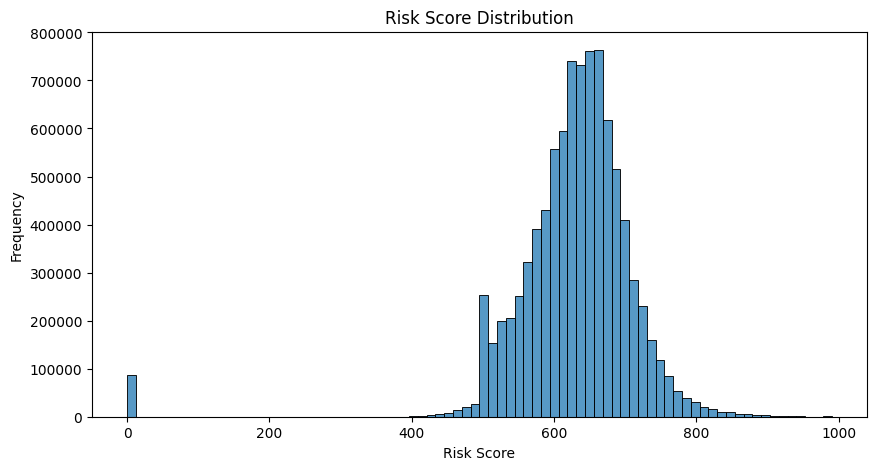

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(data=rejected_copy, x='Risk_Score', bins=80)
plt.title('Risk Score Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.show()


XGBoost handles NaNs natively, so missing scores are kept rather than filled. `0` is also a placeholder for missing.

**Finding:** missingness spikes in Nov 2013, when rejected scores switch from FICO to VantageScore, and rises to 46–93% from 2015.

In [22]:
rejected_copy['Year'] = rejected_copy['Date'].dt.year.astype('int16')

col = 'Risk_Score'

check = rejected_copy.groupby('Year').agg(
    applications=(col, 'size'),
    na_pct=(col, lambda s: s.isna().mean() * 100),
    zero_pct=(col, lambda s: (s == 0).mean() * 100),
    median_score=(col, lambda s: s[s > 0].median()),
).round(2)
check

/tmp/ipykernel_4094/106216040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rejected_copy['Year'] = rejected_copy['Date'].dt.year


,applications,na_pct,zero_pct,median_score
Year,,,,
2007,5272,1.95,4.23,576.0
2008,25589,9.78,4.02,613.0
2009,56950,10.91,5.82,638.0
2010,112314,7.08,8.46,654.0
2011,217325,1.27,8.99,650.0
2012,336647,1.28,5.51,651.0
2013,757856,3.10,4.47,649.0
2014,1918543,12.63,0.00,638.0
2015,2847734,82.09,0.00,641.0


In [23]:
window = rejected_copy[(rejected_copy['Date'] >= '2013-06-01') &
                       (rejected_copy['Date'] < '2014-06-01')]

monthly = window.groupby(window['Date'].dt.to_period('M')).agg(
    na_pct=(col, lambda s: s.isna().mean() * 100),
    median_score=(col, lambda s: s[s > 0].median()),
).round(2)
monthly

,na_pct,median_score
Date,,
2013-06,0.97,652.0
2013-07,1.08,644.0
2013-08,1.16,641.0
2013-09,1.19,647.0
2013-10,4.30,648.0
2013-11,18.78,658.0
2013-12,7.36,645.0
2014-01,5.89,649.0
2014-02,4.20,654.0


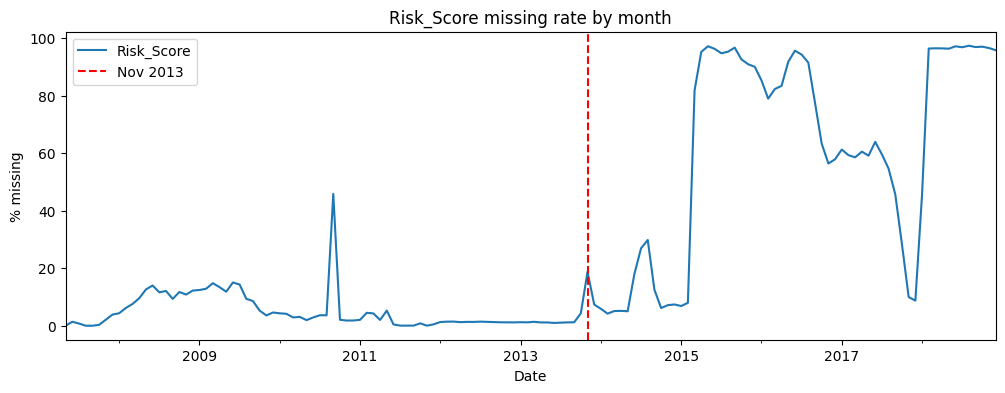

In [24]:
monthly_all = rejected_copy.groupby(rejected_copy['Date'].dt.to_period('M'))[col] \
                           .apply(lambda s: s.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_all.plot(ax=ax)
ax.axvline(pd.Period('2013-11', 'M'), color='red', linestyle='--', label='Nov 2013')
ax.set_ylabel('% missing')
ax.set_title('Risk_Score missing rate by month')
ax.legend()
plt.show()

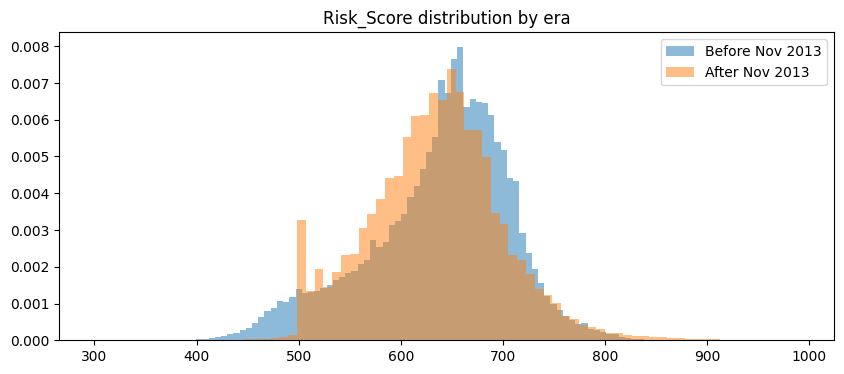

In [25]:
valid = rejected_copy[rejected_copy[col] > 0]
before = valid.loc[valid['Date'] < '2013-11-05', col]
after = valid.loc[valid['Date'] >= '2013-11-05', col]

plt.figure(figsize=(10, 4))
plt.hist(before, bins=80, alpha=0.5, density=True, label='Before Nov 2013')
plt.hist(after, bins=80, alpha=0.5, density=True, label='After Nov 2013')
plt.legend()
plt.title('Risk_Score distribution by era')
plt.show()

## Accepted columns to match
Find the accepted columns that correspond to the rejected ones (e.g. the FICO range for `Risk_Score`).

In [ ]:
# all 151 columns in the file (only ACC_COLS are loaded)
list(pd.read_csv(ACC_PATH, nrows=0).columns)

In [28]:
accepted

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
accepted['fico_range_high']

,fico_range_high
0,679.0
1,719.0
2,699.0
3,789.0
4,699.0
...,...
2260696,709.0
2260697,664.0
2260698,664.0
2260699,NaN


In [30]:
accepted['fico_range_low']

,fico_range_low
0,675.0
1,715.0
2,695.0
3,785.0
4,695.0
...,...
2260696,705.0
2260697,660.0
2260698,660.0
2260699,NaN


# Shared schema
The rejected file only has 9 columns, so both files are reduced to the same 8 features plus an `accepted` label:
`amount`, `date`, `purpose`, `risk_score`, `dti`, `zip3`, `state`, `emp_length`.

`Policy Code` is dropped: it is 0 for every rejected row and 1 for every accepted row, so it would leak the label.

## Year cut-off
- Data ends Dec 2018. Unfinished loans are mostly good ones (bad loans fail early), so dropping them inflates the default rate.
- **Outcome data:** only loans issued at least term + 12 months before Dec 2018 (36-month before 2015, 60-month before 2013).
- **Combined data:** all years kept, with `in_ope_period` = 1 for applications before 2015. Train the propensity model on all years (with `year` as a feature); run IPS/DR and calibration checks on flagged rows only.

In [31]:
DATA_END = pd.Timestamp('2018-12-31')   # last month in the data
BUFFER_MONTHS = 12                       # time for a late loan to be charged off
CUTOFF = pd.Timestamp('2015-01-01')      # 36-month term + 12-month buffer before DATA_END

# where the parquet files are saved; to use Google Drive instead:
# from google.colab import drive; drive.mount('/content/drive'); OUT_DIR = '/content/drive/MyDrive'
OUT_DIR = '.'

In [ ]:
# drop leftover names (the raw rejected frame was freed earlier; accepted_copy still holds the accepted data)
del accepted, rejected_copy0
gc.collect()

In [33]:
def clean_emp_length(s):
    # '< 1 year' -> 0, '1 year' -> 1, '10+ years' -> 10, 'n/a' / NaN -> NaN
    return (s.str.replace('< 1 year', '0', regex=False)
             .str.extract(r'(\d+)')[0]
             .astype(float))


# keyword rules that map free-text loan titles onto Lending Club's purpose categories
# order matters: the first rule that matches wins
PURPOSE_RULES = [
    ('credit_card',        r'credit card|\bcc\b|\bcards?\b'),
    ('debt_consolidation', r'consolid|debt|refinanc|pay ?off|bills'),
    ('home_improvement',   r'home improv|remodel|renovat|repair|kitchen|bathroom|\broof'),
    ('house',              r'house|home|mortgage|down payment|real estate'),
    ('car',                r'\bcar\b|\bauto|vehicle|truck|motorcycle'),
    ('medical',            r'medic|surgery|dental|hospital|doctor|health'),
    ('small_business',     r'business|start ?up|inventory|equipment'),
    ('wedding',            r'wedding|engagement'),
    ('moving',             r'moving|relocat|\bmove'),
    ('vacation',           r'vacation|travel|\btrip|holiday'),
    ('educational',        r'school|tuition|student|educat|college'),
    ('renewable_energy',   r'solar|renewable'),
    ('major_purchase',     r'purchase|furniture|computer|appliance'),
]


def map_categories(s, func):
    # apply func once per distinct value instead of once per row (fast and light on ~27M rows);
    # returns a categorical, so cast numeric results with .astype(float)
    s = s.astype('category')
    new_cat = pd.Categorical(func(pd.Series(s.cat.categories)))
    old_codes = s.cat.codes.to_numpy()
    new_codes = np.asarray(new_cat.codes)
    codes = np.where(old_codes >= 0, new_codes[old_codes], -1)
    return pd.Series(pd.Categorical.from_codes(codes, new_cat.categories), index=s.index)


def title_to_purpose(titles):
    def label(uniq):
        norm = (uniq.astype(str).str.lower()
                    .str.replace('_', ' ', regex=False)
                    .str.replace(r'\s+', ' ', regex=True)
                    .str.strip())
        conds = [norm.str.contains(p, regex=True) for _, p in PURPOSE_RULES]
        return np.select(conds, [name for name, _ in PURPOSE_RULES], default='other')

    out = map_categories(titles, label)
    if 'other' not in out.cat.categories:
        out = out.cat.add_categories('other')
    return out.fillna('other')

## Rejected → shared schema
DTI text `"38.64%"` → `38.64`; zip `"481xx"` → `481`.

In [34]:
rej = pd.DataFrame({
    'amount':     rejected_copy['Amount Requested'],
    'date':       rejected_copy['Date'],
    'purpose':    title_to_purpose(rejected_copy['Loan Title']),
    'risk_score': rejected_copy['Risk_Score'],
    'dti':        map_categories(rejected_copy['Debt-To-Income Ratio'],
                                lambda c: pd.to_numeric(c.str.rstrip('%'), errors='coerce')).astype(float),
    'zip3':       map_categories(rejected_copy['Zip Code'], lambda c: c.str[:3]),
    'state':      rejected_copy['State'],
    'emp_length': map_categories(rejected_copy['Employment Length'], clean_emp_length).astype(float),
})
rej['id'] = np.nan
rej['accepted'] = 0
rej.head()

,amount,date,purpose,risk_score,dti,zip3,state,emp_length,id,accepted
0,1000.0,2007-05-26,wedding,693.0,10.00,481,NM,4.0,NaN,0
1,1000.0,2007-05-26,debt_consolidation,703.0,10.00,010,MA,0.0,NaN,0
2,11000.0,2007-05-27,debt_consolidation,715.0,10.00,212,MD,1.0,NaN,0
3,6000.0,2007-05-27,other,698.0,38.64,017,MA,0.0,NaN,0
4,1500.0,2007-05-27,other,509.0,9.43,209,MD,0.0,NaN,0


## Accepted → shared schema
- Footer rows without a numeric `id` are removed.
- Risk score = midpoint of the FICO range.
- Same title → purpose mapper as rejected (empty titles filled with `purpose`).

In [35]:
acc = pd.DataFrame({
    'id':         pd.to_numeric(accepted_copy['id'], errors='coerce'),
    'amount':     accepted_copy['loan_amnt'],
    'date':       pd.to_datetime(accepted_copy['issue_d'], format='%b-%Y', errors='coerce'),
    'purpose':    title_to_purpose(accepted_copy['title'].fillna(accepted_copy['purpose'])),
    'risk_score': (accepted_copy['fico_range_low'] + accepted_copy['fico_range_high']) / 2,
    'dti':        accepted_copy['dti'],
    'zip3':       accepted_copy['zip_code'].str[:3],
    'state':      accepted_copy['addr_state'],
    'emp_length': clean_emp_length(accepted_copy['emp_length']),
})
acc = acc.dropna(subset=['id']).drop_duplicates(subset='id')
acc['accepted'] = 1
acc.head()

,id,amount,date,purpose,risk_score,dti,zip3,state,emp_length,accepted
0,68407277.0,3600.0,2015-12-01,debt_consolidation,677.0,5.91,190,PA,10.0,1
1,68355089.0,24700.0,2015-12-01,small_business,717.0,16.06,577,SD,10.0,1
2,68341763.0,20000.0,2015-12-01,home_improvement,697.0,10.78,605,IL,10.0,1
3,66310712.0,35000.0,2015-12-01,debt_consolidation,787.0,17.06,076,NJ,10.0,1
4,68476807.0,10400.0,2015-12-01,major_purchase,697.0,25.37,174,PA,3.0,1


## Concatenate
- Dates rounded to the month: accepted only has the issue month, so the exact day would reveal a rejection.
- Placeholders → NaN: DTI < 0 or > 100, risk score outside 300–990.
- Rows missing amount, date, state or zip are dropped.
- `in_ope_period` flag added; no rows are removed by date.

In [ ]:
# give the text columns the same categories in both frames, so the concatenated
# ~30M rows stay compact categoricals instead of plain text
for c in ['purpose', 'state', 'zip3']:
    cats = acc[c].astype('category').cat.categories.union(rej[c].astype('category').cat.categories)
    acc[c] = acc[c].astype(pd.CategoricalDtype(cats))
    rej[c] = rej[c].astype(pd.CategoricalDtype(cats))

combined = pd.concat([acc, rej], ignore_index=True)
# rejected_copy is no longer needed and the combined data is ~30M rows, so free the memory
del acc, rej, rejected_copy
gc.collect()

combined['date'] = combined['date'].dt.to_period('M').dt.to_timestamp()
combined['in_ope_period'] = (combined['date'] < CUTOFF).astype('int8')
combined['year'] = combined['date'].dt.year.astype('int16')
combined['month'] = combined['date'].dt.month.astype('int8')

combined.loc[(combined['dti'] < 0) | (combined['dti'] > 100), 'dti'] = np.nan
combined.loc[(combined['risk_score'] < 300) | (combined['risk_score'] > 990), 'risk_score'] = np.nan
# zip codes that aren't 3 digits become NaN (checked once per distinct value)
zip_cats = combined['zip3'].cat.categories
combined['zip3'] = combined['zip3'].cat.remove_categories(zip_cats[~zip_cats.astype(str).str.fullmatch(r'\d{3}')])

combined = combined.dropna(subset=['amount', 'date', 'state', 'zip3'])
combined = combined[combined['amount'] > 0]

combined['accepted'] = combined['accepted'].astype('int8')
combined = combined.reset_index(drop=True)

combined.info()

## Checks
**Last run (pre-2015 only):** 466,345 accepted / 3,430,473 rejected. Rejected applicants have a lower median risk score (643 vs 692) and a median employment length of 0 vs 6 years.

In [ ]:
print(combined.shape)
print(combined['accepted'].value_counts(), '\n')
print('Missing values (%):')
print((combined.isna().mean() * 100).round(2), '\n')
combined.groupby('accepted')[['amount', 'risk_score', 'dti', 'emp_length']].median()

In [ ]:
# applications per year: rejections grow sharply after 2014
# (a good figure for the data section)
by_year = pd.crosstab(combined['year'], combined['accepted']).rename(columns={0: 'rejected', 1: 'accepted'})
by_year['rejected_per_accepted'] = (by_year['rejected'] / by_year['accepted']).round(1)
print(combined.groupby('in_ope_period')['accepted'].value_counts().unstack(), '\n')
by_year

In [ ]:
# share of each purpose within accepted vs rejected
pd.crosstab(combined['purpose'], combined['accepted'], normalize='columns').round(3)

In [ ]:
combined.to_parquet(os.path.join(OUT_DIR, 'lending_club_combined.parquet'), index=False)

# Outcome dataset
Accepted loans only, after the year cut-off, with a finished status. Target `default` = Charged Off or Default.

13 pre-decision features are added. `grade`, `sub_grade`, `int_rate` and `installment` are excluded (Lending Club's own pricing); the official purpose is kept as `lc_purpose`.

**Last run:** 358,894 loans, 13.9% default. The 36-month default rate is stable at ~11–14% from 2009–2014, so the cut-off worked.

In [ ]:
finished = ['Fully Paid', 'Charged Off', 'Default',
            'Does not meet the credit policy. Status:Fully Paid',
            'Does not meet the credit policy. Status:Charged Off']

# pre-decision information only: grade, sub_grade, int_rate and installment are excluded
# because they are Lending Club's own pricing decision, set after assessing the applicant
outcome_features = ['term', 'annual_inc', 'home_ownership', 'verification_status', 'lc_purpose',
                    'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'delinq_2yrs',
                    'inq_last_6mths', 'pub_rec', 'mort_acc']

# Lending Club's official purpose is renamed so it is not confused with the shared
# `purpose` column, which is derived from the loan title for both datasets
outcome = (accepted_copy.rename(columns={'purpose': 'lc_purpose'})
           [['id', 'issue_d', 'loan_status'] + outcome_features].copy())
outcome['id'] = pd.to_numeric(outcome['id'], errors='coerce')
outcome = outcome.dropna(subset=['id']).drop_duplicates(subset='id')
outcome['term'] = outcome['term'].str.extract(r'(\d+)')[0].astype(float)  # ' 36 months' -> 36

# year cut-off: keep loans observed for at least their full term + buffer
issue = pd.to_datetime(outcome['issue_d'], format='%b-%Y', errors='coerce')
months_observed = (DATA_END.year - issue.dt.year) * 12 + (DATA_END.month - issue.dt.month)
outcome = outcome[months_observed >= outcome['term'] + BUFFER_MONTHS]

print('Status of loans after the cut-off (should be almost all finished):')
print(outcome['loan_status'].value_counts(), '\n')
outcome = outcome[outcome['loan_status'].isin(finished)]

outcome['default'] = outcome['loan_status'].str.contains('Charged Off|Default').astype('int8')
outcome['revol_util'] = pd.to_numeric(outcome['revol_util'].astype(str).str.rstrip('%'), errors='coerce')
for c in ['home_ownership', 'verification_status', 'lc_purpose']:
    outcome[c] = outcome[c].astype('category')
outcome = outcome.drop(columns=['issue_d', 'loan_status'])

# add the shared columns so the outcome model sees the same inputs as the propensity model
outcome = (combined[combined['accepted'] == 1].drop(columns=['accepted', 'in_ope_period'])
           .merge(outcome, on='id', how='inner'))

print(outcome.shape)
print(outcome['default'].value_counts(normalize=True).round(3))
outcome.head()

In [ ]:
# default rate by issue year and term - should NOT climb sharply in the last years
# (a sharp climb would mean unfinished good loans are still being dropped)
outcome.pivot_table(index='year', columns='term', values='default', aggfunc=['mean', 'size']).round(3)

In [ ]:
outcome.to_parquet(os.path.join(OUT_DIR, 'lending_club_outcome.parquet'), index=False)

In [ ]:
# file sizes in MB
for f in ['lending_club_combined.parquet', 'lending_club_outcome.parquet']:
    print(f, round(os.path.getsize(os.path.join(OUT_DIR, f)) / 1e6, 1))

# Summary
- **`lending_club_combined.parquet`:** accepted + rejected, 2007–2018, 8 shared features, `accepted` label, `in_ope_period` flag. Used for the propensity model.
- **`lending_club_outcome.parquet`:** finished accepted loans before the cut-off, 13 extra pre-decision features, `default` target. Used for the outcome model.
- **Leakage removed:** `Policy Code`, the exact day of the month, Lending Club's pricing columns.
- **Limitations:** rejected risk scores switch to VantageScore from Nov 2013; risk score missingness differs between groups; application date (rejected) vs issue date (accepted); ~12:1 class imbalance; policy value estimates only describe 2007–2014.